In [1]:
## Week 2 
import sklearn
import sklearn.datasets

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Dataset preparison

In [3]:
x1 = np.random.multivariate_normal(mean = [1, 1], cov = [[1,0],[0,1]], size = 100) # means of X is one, mean of Y is one 
# Covariance matrix cov = [[1,0],[0,1]] 2* 2 

In [4]:
x2 = np.random.multivariate_normal(mean = [3, 1], cov = [[1,0],[0,1]], size = 100)
x3 = np.random.multivariate_normal(mean = [2, 2], cov = [[1,0],[0,1]], size = 100)

In [5]:
X = np.vstack([x1, x2, x3]) # stack x1, x2 ,x3 vertically 

In [6]:
y = np.concatenate([np.repeat(0,200), np.repeat(1,100)]) # np.hstack 

In [7]:
# what does this y stands for ? 
# here y is the label 
# That means we manually give X1, X2 with label 0 and X3 with label 1

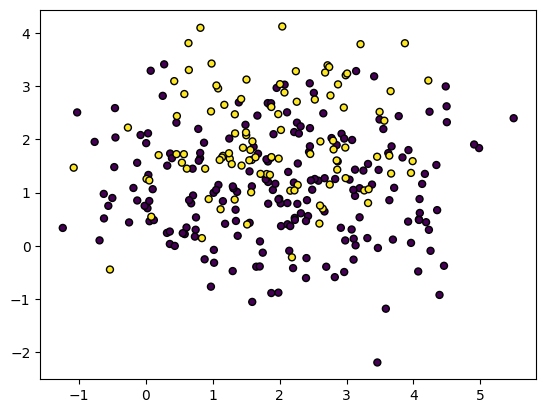

In [8]:
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=25, edgecolor='k') # X[:, 0] means we want the first columns of the dataset ! 
plt.show()

In [9]:
# Testing data
x1 = np.random.multivariate_normal(mean = [1, 1], cov = [[1,0],[0,1]], size = 100)
x2 = np.random.multivariate_normal(mean = [3, 1], cov = [[1,0],[0,1]], size = 100)
x3 = np.random.multivariate_normal(mean = [2, 2], cov = [[1,0],[0,1]], size = 100)

In [10]:
Xtest = np.vstack([x1, x2, x3]) 
ytest = np.concatenate([np.repeat(0,200), np.repeat(1,100)]) 

## Training, Testing part 

In [11]:
# Three conditions 
# 1. Training dataset and Testing set both good ? => This is a great model 
# 2. Training dataset perform quite well but performs quite bad on the testing dataset? => This model is overfitting 
# 3. Training dataset bad, Testing dataset bad = > Underfitting, we need to retrain this model or change a better one 

In [12]:
# What is the difference between hyper-parameter and parameter ? 
# Hyper-parameter is pre-set before training process and is not fitted by the model! Setting by your self instead of learning from the model. 
from sklearn import svm
m = svm.SVC(kernel='poly', C=1, degree = 1, coef0 = 1) # C, degree , coef0 are hyperparameters in this case . 
m.fit(X, y) # model fitting 

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",1
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
m.score(X, y) # training accuracy

0.72

In [14]:
m.score(Xtest, ytest) # test accuracy

0.7333333333333333

In [21]:
# Hypterpam = svm.SVC(kernel='poly', C=1, degree = 1, coef0 = 1) # C, degree , coef0 are hyperparameters in this case . 
m = svm.SVC(kernel='poly', C=0.1, degree = 5, coef0 = 4)
# C does not influence our output a lot 
m.fit(X, y) # model fitting 
# parameter tuning 
print(m.score(X, y)) # training accuracy
print(m.score(Xtest, ytest)) # test accuracy

0.73
0.74


In [22]:
def trainAccuracy(C = 1):
    m = svm.SVC(kernel='poly', C=C, degree = 2, coef0 = 1)
    m.fit(X, y)
    return(m.score(X, y))
def testAccuracy(C = 1):
    m = svm.SVC(kernel='poly', C=C, degree = 2, coef0 = 1)
    m.fit(X, y)
    return(m.score(Xtest, ytest))

In [34]:
Cset = 2.0**np.arange(-5,5)

In [33]:
# generate a sequence with the same gap, the default gap is zero 
# the first argument is the staring point while the second argument is NOT included in the resulting sequence! 
# np.arange(1,11) # with the default gap/step as 1 

In [32]:
# 2.0*np.arange(-5,5)  # * denotes for multiplication 
# 2.0**np.arange(-5,5) # 2 ** -5

In [48]:
## view the change in train and test error with respect to C
trainAcc = []
for i in range(len(Cset)):
    result = trainAccuracy(Cset[i])
    trainAcc.append(result)

In [49]:
testAcc = []
for i in range(len(Cset)):
    result = testAccuracy(Cset[i])
    testAcc.append(result)

In [50]:
trainAcc = np.array(trainAcc)
testAcc = np.array(testAcc)

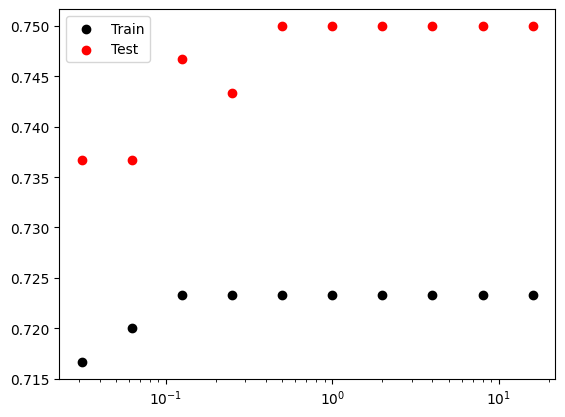

In [51]:
plt.xscale('log') # we take 2 ** C
plt.scatter(Cset, trainAcc, c = 'k', label = "Train")
plt.scatter(Cset, testAcc, c = 'r', label = "Test")
plt.legend()
plt.show()

## Cross Validation

In [52]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
## compute the set of CV splits, here we set the number of partitions to 10
kf = KFold(n_splits=10) 
## compute the accuracy for each CV split
m = svm.SVC(kernel='poly', C=1, degree = 1, coef0 = 1)
score = cross_val_score(m, X, y, cv=kf)
## compute the mean accuracy over all CV splits
cvScore = score.mean()
print(cvScore)

0.5633333333333334


In [53]:
def cvAccuracy(C = 1):
    kf = KFold(n_splits=10)
    m = svm.SVC(kernel='poly', C=C, degree = 2, coef0 = 1)
    score = cross_val_score(m, X, y, cv=kf)
    cvScore = score.mean()
    return(cvScore)

In [54]:
cvTrainAcc = [cvAccuracy(C = C) for C in Cset]

In [59]:
m.fit(X, y)
m.score(Xtest, ytest)

0.7333333333333333

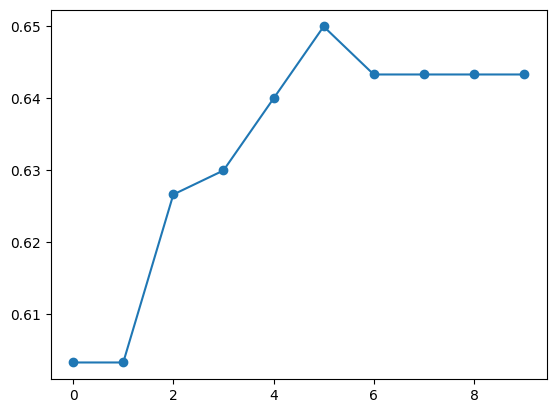

In [58]:
plt.plot(cvTrainAcc, marker = 'o')

In [60]:
from sklearn.model_selection import GridSearchCV
## set the search to examine gamma from 2ˆ-5 to 2ˆ4 and C from 2ˆ-5 to 2ˆ4
parameterSet = [{'kernel': ['poly'], 'degree': np.arange(1,5),
'coef0' : [1], 'C': 2.0**np.arange(-5,5)}]
m = svm.SVC()
gsm = GridSearchCV(m, parameterSet, cv=5)
gsm.fit(X, y)
## print the parameters that provide the greatest accuracy
gsm.best_params_

{'C': np.float64(2.0), 'coef0': 1, 'degree': np.int64(3), 'kernel': 'poly'}

## Compare the performance of Bayes and SVM

In [70]:
from scipy.stats import multivariate_normal
d1 = multivariate_normal(mean = [1, 1], cov = [[1,0],[0,1]])
d2 = multivariate_normal(mean = [3, 1], cov = [[1,0],[0,1]])
d3 = multivariate_normal(mean = [2, 2], cov = [[1,0],[0,1]])

In [72]:
# Compute the density of each point using pdf, which is the probability density 
p1 = d1.pdf(X)
p2 = d2.pdf(X)
p3 = d3.pdf(X)

In [73]:
pxC0 = 0.5*p1 + 0.5*p2 # training dataset
pxC1 = p3

In [75]:
# then compute the probabiliy of each point being class 1 
pY1 = (pxC1/3) / (pxC0*2/3 + pxC1/3)
# compute tje probablity of each point being class 0
pY0 = (pxC0*2/3) / (pxC0*2/3 + pxC1/3)

In [85]:
# because for each point we have a probability for label 1 as well as label 0 
# negative if y= 0 is more likely 
# np.log(pY1/pY0)

In [86]:
# To test the accurary 
np.mean(np.round(pY1) == y)

np.float64(0.7066666666666667)

In [87]:
# Here, it seems like the Bayes method reach a quite compatitive performance than SVM
# Hoewever, we are cheating since we are using the prioir information that is unavailable in real world applications 
# 1. We do not have the exact statistical distribution that generate our dataset 
# 2. We do not know the exact proportion of the training data and testing data.... 